In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [3]:
filenames = [0,2,3,4,5]

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[0, 2, 3, 4, 5]

0


Label
1    514148
2    329224
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


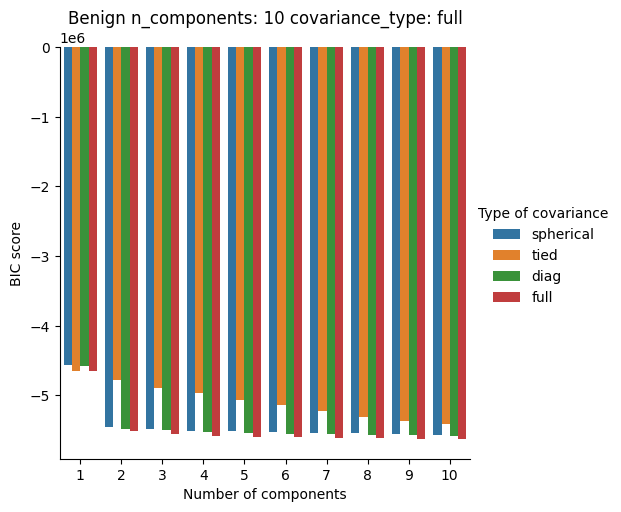

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


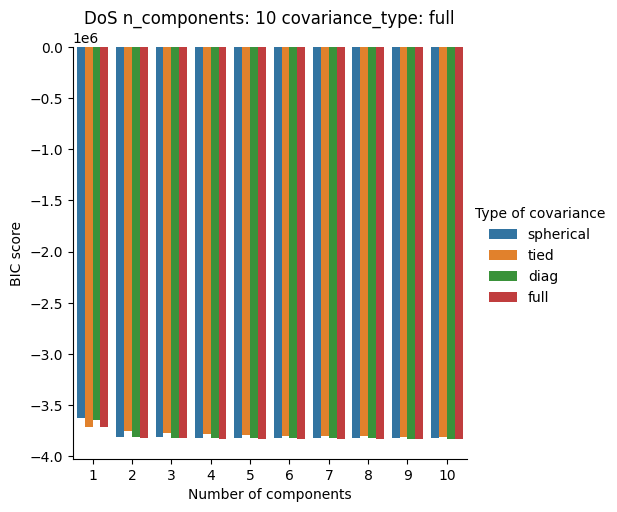

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 3 covariance_type: full


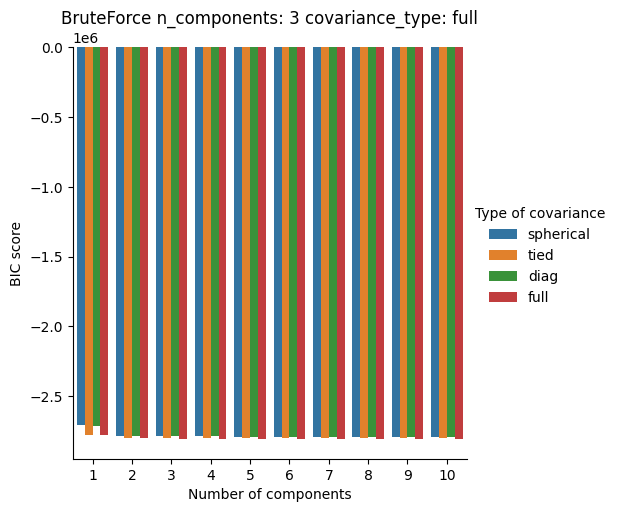

Tipo: 4 = Bot
Melhor modelo: n_componentes: 7 covariance_type: full


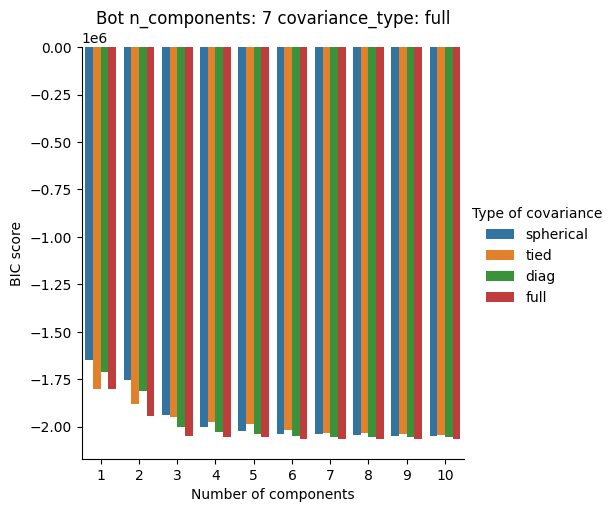

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


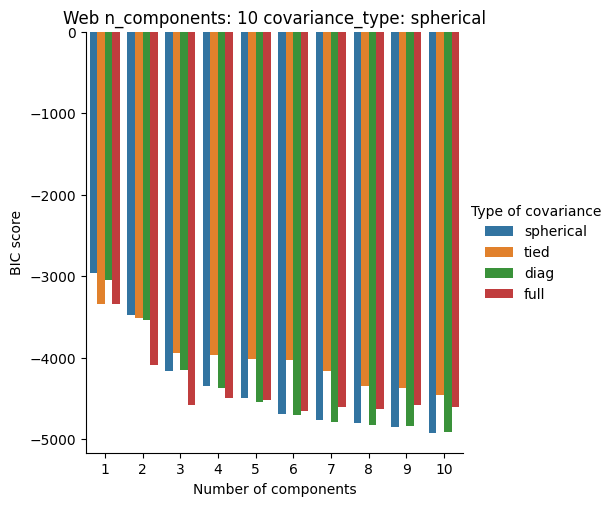

,0,1,2,3,4,5
0,NaN,27.386493,6.102262,-61.713494,9.951572,13.937976
1,NaN,10.037981,29.599756,7.328385,-24.718106,1.928398
2,NaN,28.434973,4.680794,-67.159200,10.640768,13.989704
3,NaN,11.501651,-12.826302,29.162601,-40.117014,0.405869
4,NaN,28.559719,7.786686,-58.022213,11.708972,13.932336
...,...,...,...,...,...,...
519951,NaN,28.101396,3.383262,-73.482217,10.036214,14.200832
519952,NaN,14.212925,-29.144809,-40.990194,29.180752,13.140523
519953,NaN,19.719536,-2.308385,-89.543216,5.301330,14.117839
519954,NaN,27.910963,4.874603,-73.243675,9.129186,14.111537


,0,1,2,3,4,5
0,NaN,19.736852,-2.213376,-89.131748,5.383825,14.117484
1,NaN,27.023370,5.397446,-64.045205,9.617411,13.978679
2,NaN,28.140369,5.879139,-60.288865,11.705597,13.800185
3,NaN,26.077971,8.450837,-49.466193,11.976774,13.492181
4,NaN,18.619948,11.625724,-18.694327,16.356278,11.553908
...,...,...,...,...,...,...
649942,NaN,28.566712,7.620784,-59.017773,11.555366,13.952316
649943,NaN,18.388612,12.369678,-12.962463,16.136052,11.096096
649944,NaN,18.490979,12.190480,-14.654833,16.229563,11.263000
649945,NaN,11.760481,-11.680238,28.901915,-35.709349,1.113973


2


Label
0    808919
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


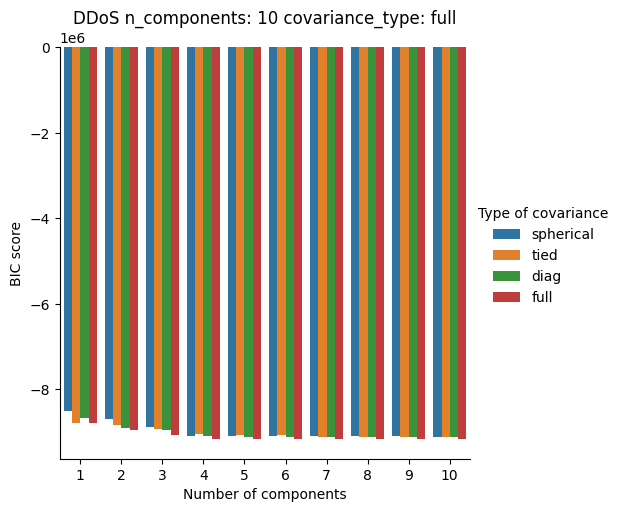

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


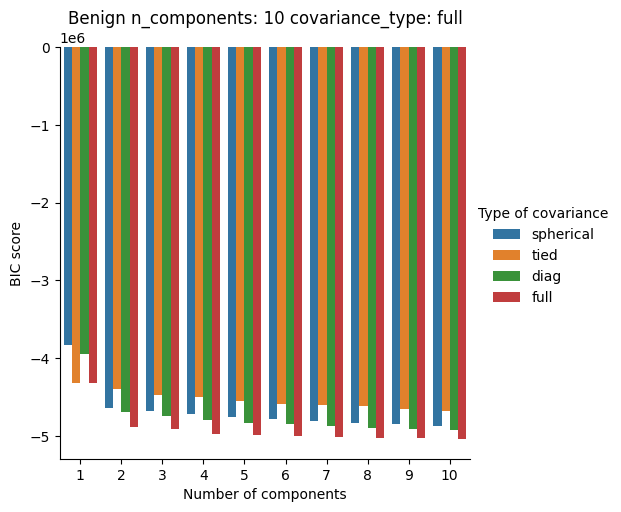

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


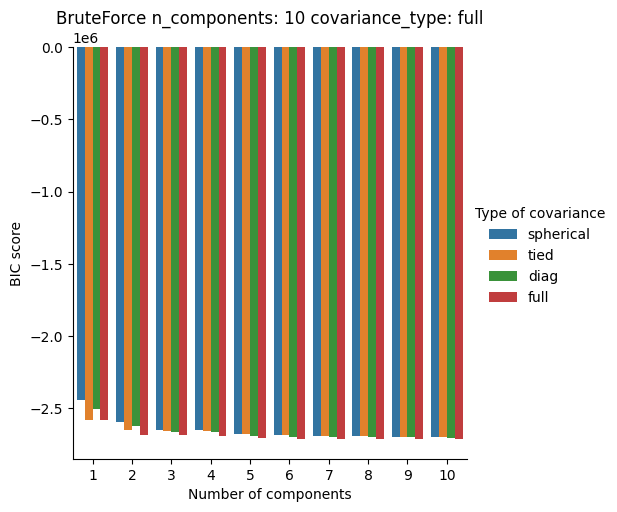

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


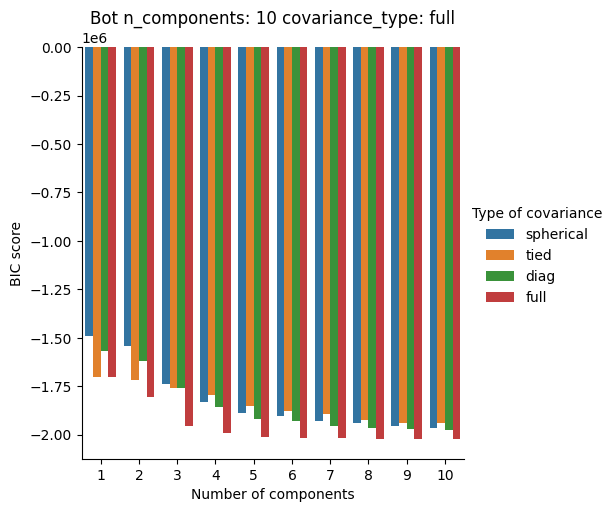

Tipo: 5 = Web
Melhor modelo: n_componentes: 3 covariance_type: full


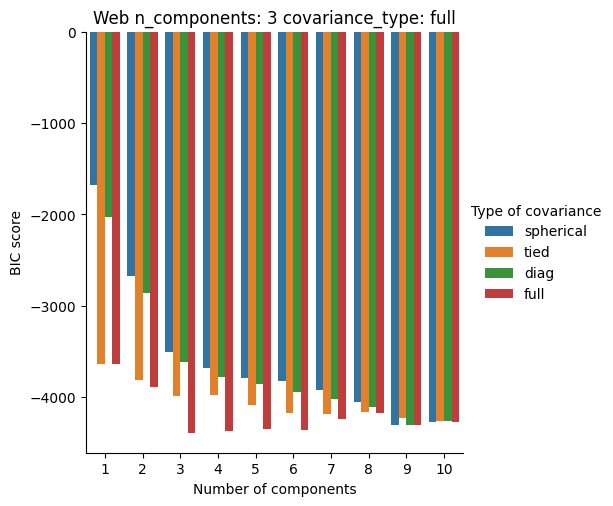

,0,1,2,3,4,5
0,28.239029,13.688126,NaN,-523.816922,4.056261,11.151121
1,-260.142856,8.396891,NaN,-58.816373,0.337891,10.789782
2,-24.088672,25.388180,NaN,-118.583685,14.463994,15.648776
3,-312.040228,9.692656,NaN,28.140804,-455.690928,-133.959406
4,-1.817304,26.777944,NaN,-110.405148,14.835194,15.815359
...,...,...,...,...,...,...
519951,-8.369481,24.825672,NaN,-109.825354,14.186680,15.749512
519952,-234.540102,10.283924,NaN,-112.976040,29.164420,15.568669
519953,28.957168,15.963568,NaN,-550.575459,2.996008,10.671365
519954,-9.422602,24.930263,NaN,-113.569779,13.231684,14.536268


,0,1,2,3,4,5
0,28.820139,16.163937,NaN,-543.955508,3.418842,10.894551
1,28.081066,13.092428,NaN,-524.380929,3.919959,11.098578
2,-8.648855,23.881515,NaN,-130.596784,13.066383,15.152560
3,-51.091078,18.265266,NaN,-122.952864,14.038093,14.949976
4,28.632756,15.353351,NaN,-539.240110,3.372819,10.969648
...,...,...,...,...,...,...
649942,-4.328043,26.329020,NaN,-122.669123,14.926828,15.833524
649943,28.628804,15.441328,NaN,-540.211452,3.268292,10.924053
649944,28.634400,15.382403,NaN,-542.988152,2.941958,10.799597
649945,-297.753839,10.164049,NaN,28.207457,-437.325804,-128.956323


3


Label
0    808919
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


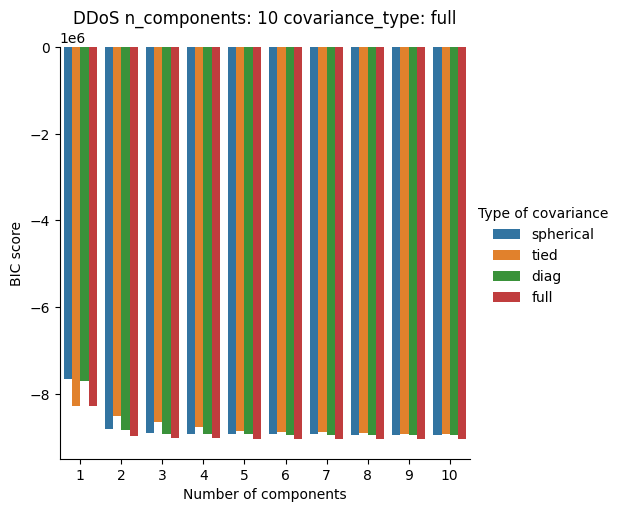

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


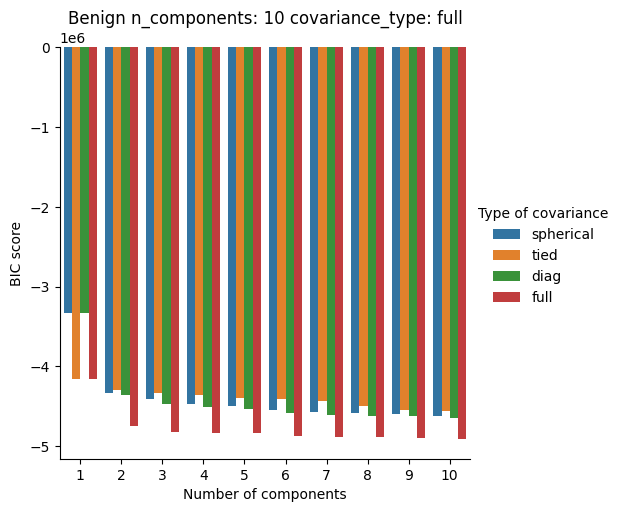

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


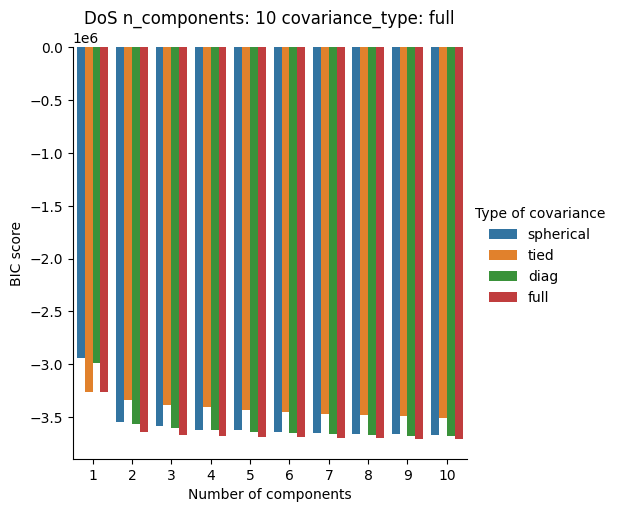

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


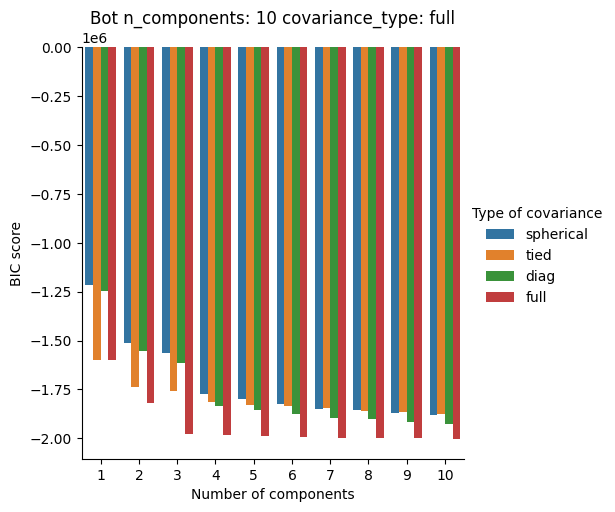

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: full


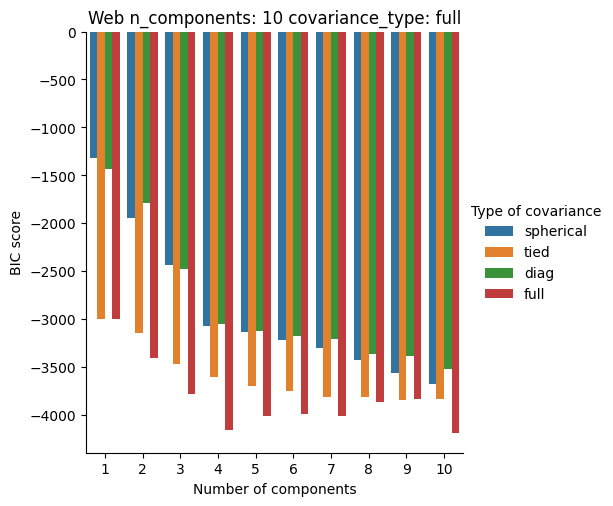

,0,1,2,3,4,5
0,28.573294,10.441600,-4.447166,NaN,-1.257428,1.562103
1,-75.263292,8.300224,29.396083,NaN,-26.312884,-138.551251
2,2.837443,24.653870,-18.997081,NaN,7.783310,-34.913836
3,-80.485507,8.511481,19.445282,NaN,-29.329434,-144.099935
4,5.910929,26.771227,-10.976003,NaN,9.131808,-15.072169
...,...,...,...,...,...,...
519951,4.308599,26.764775,-14.091357,NaN,8.395796,-19.603645
519952,-47.628122,9.095252,-87.411341,NaN,29.122876,-2.848343
519953,28.784309,10.042259,-5.065158,NaN,-1.046293,4.329319
519954,6.559076,24.288897,-16.365912,NaN,15.137044,-40.832258


,0,1,2,3,4,5
0,28.649997,10.025838,-5.046255,NaN,-1.006707,6.777398
1,28.333519,10.439233,-4.276771,NaN,-1.150631,5.681006
2,5.850346,20.238637,-5.512339,NaN,9.686652,-5.381817
3,4.777277,18.096588,-20.246508,NaN,7.541293,-135.955362
4,27.556437,10.737348,-2.896793,NaN,-1.415897,-7.821597
...,...,...,...,...,...,...
649942,5.492993,26.600065,-11.749690,NaN,8.915552,-13.675225
649943,26.989296,10.738143,-2.410157,NaN,-1.145691,-6.795472
649944,27.615951,10.708564,-2.809488,NaN,-1.383849,-4.068919
649945,-107.413379,7.804498,13.811243,NaN,-39.016530,-125.826333


4


Label
0    808919
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 9 covariance_type: full


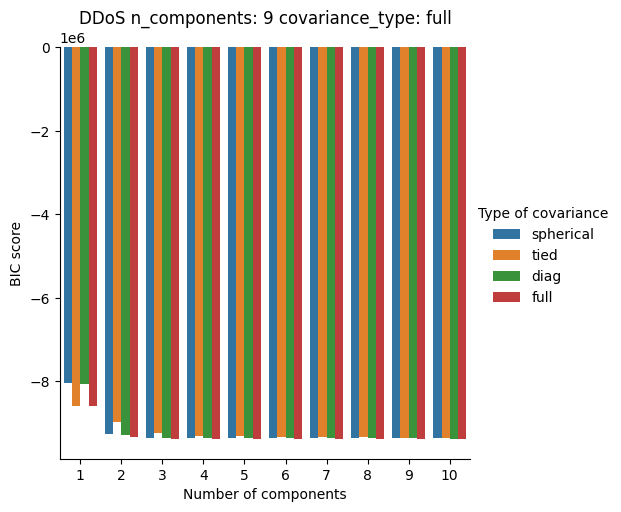

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


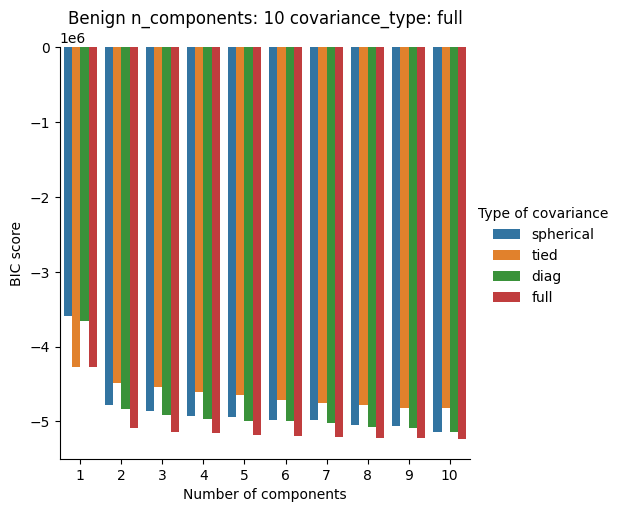

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


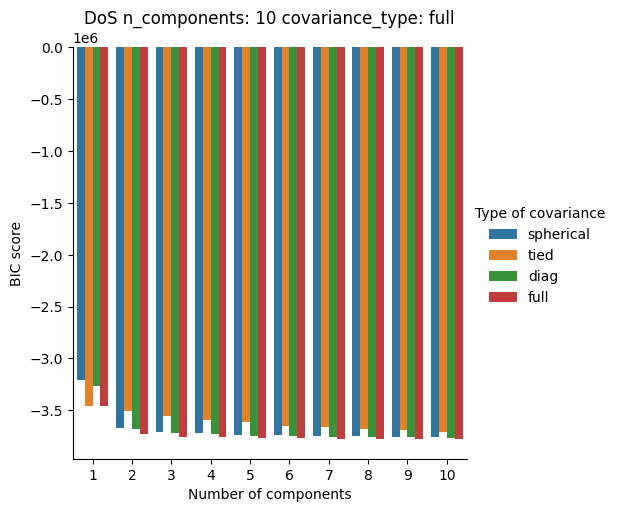

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 6 covariance_type: full


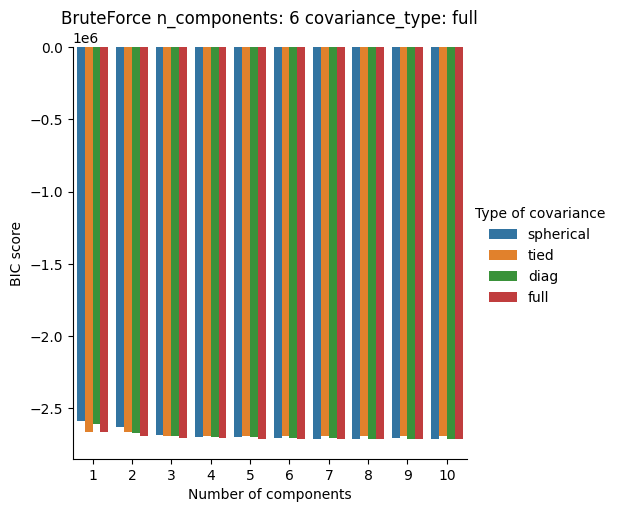

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


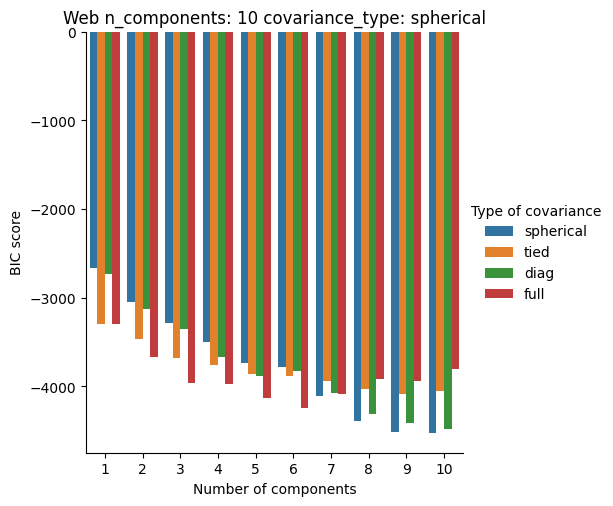

,0,1,2,3,4,5
0,29.352104,16.807811,-229.406593,-469.158715,NaN,0.511147
1,-355.718030,-1.355736,29.565873,-23.811203,NaN,-0.000045
2,-40.462244,26.945973,-41.457624,-1045.530796,NaN,0.938396
3,-923.355546,-3.313101,-7.097860,27.716031,NaN,0.804313
4,-25.227973,27.650746,-38.541295,-1078.537144,NaN,0.765339
...,...,...,...,...,...,...
519951,-19.815280,24.989956,-57.251940,-1275.205095,NaN,0.552984
519952,-41.882438,14.070610,-35.626249,-928.656798,NaN,0.455384
519953,29.435627,18.804557,-232.314002,-466.761856,NaN,0.536614
519954,-30.829377,27.149245,-46.662819,-1112.371220,NaN,0.807546


,0,1,2,3,4,5
0,29.450072,18.763712,-232.584964,-465.575286,NaN,0.534830
1,29.323711,16.737501,-229.088622,-472.356831,NaN,0.500223
2,-55.168145,20.912309,-24.602349,-844.355247,NaN,1.079052
3,-11.967585,21.463929,-20.361627,-894.849983,NaN,0.668836
4,28.787958,15.179365,-218.546248,-459.407670,NaN,0.554313
...,...,...,...,...,...,...
649942,-24.150636,27.613801,-40.146097,-1098.653381,NaN,0.731517
649943,27.155284,12.228921,-200.796795,-455.013867,NaN,0.587836
649944,28.266489,14.057377,-210.731783,-458.871082,NaN,0.564505
649945,-995.821881,-5.330609,-5.987847,27.690602,NaN,0.845973


5


Label
0    808919
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: diag


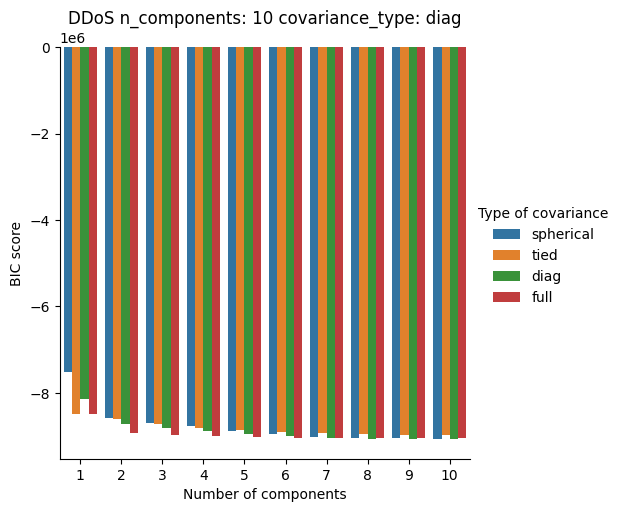

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


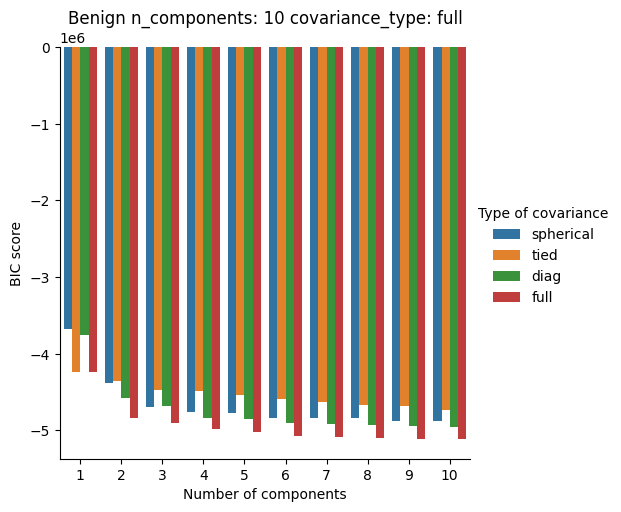

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


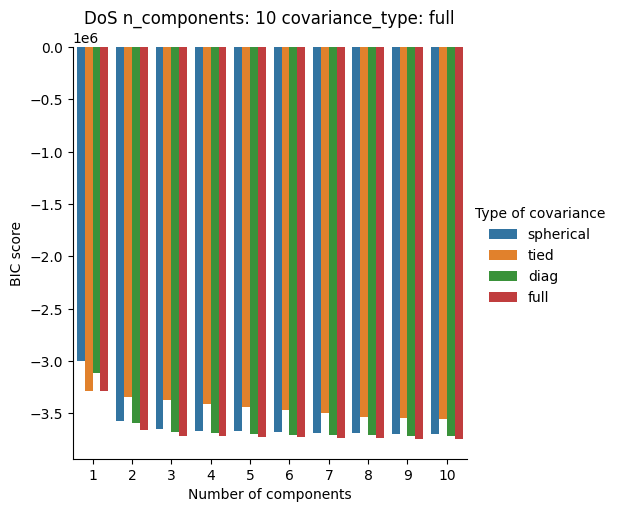

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 9 covariance_type: full


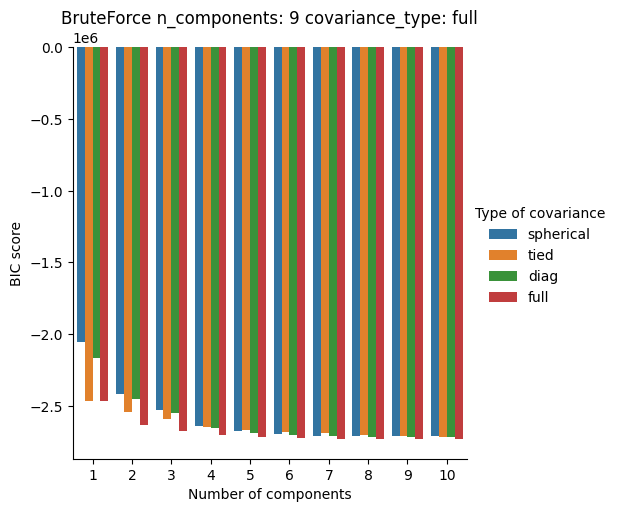

Tipo: 4 = Bot
Melhor modelo: n_componentes: 9 covariance_type: full


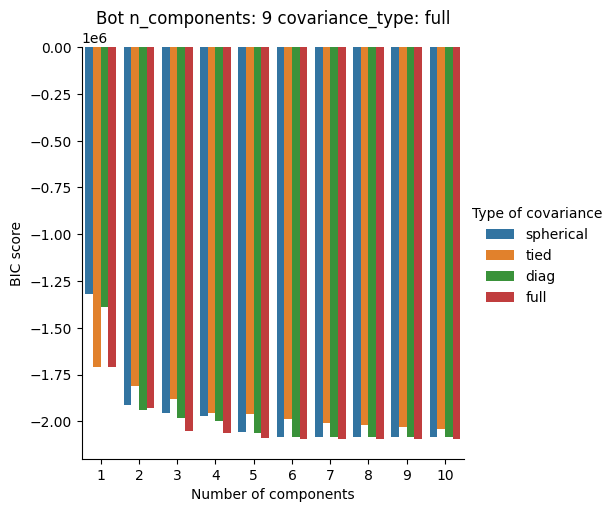

,0,1,2,3,4,5
0,28.120783,15.487245,-13.656874,-387.665673,-26.927445,NaN
1,-1144.182031,6.933632,29.402274,-28.303082,-1261.419435,NaN
2,-21.983790,25.783106,7.111365,-140.557319,16.133581,NaN
3,-1667.832445,10.734125,-3.396384,28.532819,-2420.311919,NaN
4,-44.452277,27.448275,6.199904,-126.674185,16.821096,NaN
...,...,...,...,...,...,...
519951,-31.474936,24.773148,7.119815,-122.185715,16.573874,NaN
519952,-3195.960018,10.643572,-2908.165155,-14375.105529,29.162571,NaN
519953,28.891277,18.827889,-15.092861,-414.186464,-25.407964,NaN
519954,-31.361129,25.836584,6.551640,-137.819384,15.803232,NaN


,0,1,2,3,4,5
0,28.909911,18.759101,-14.876261,-413.132164,-25.759896,NaN
1,28.024125,15.503872,-13.834555,-389.411699,-26.987471,NaN
2,-32.345578,22.728537,8.129811,-117.434875,15.059069,NaN
3,-40.068284,13.380496,4.093207,-205.639027,6.964985,NaN
4,26.113055,8.658315,-3.601722,-383.072259,-21.325163,NaN
...,...,...,...,...,...,...
649942,-45.525676,27.412388,6.182201,-129.903338,16.364539,NaN
649943,27.331857,11.013075,-6.170365,-394.075469,-21.378753,NaN
649944,27.403882,10.679515,-6.180993,-393.788796,-21.395650,NaN
649945,-1650.660757,10.577130,-3.122594,28.007676,-2376.449882,NaN


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_val = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_val = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_val.append(val_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = val_encoded_df["Label"].values
    scores_df.to_csv(f'val_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)